In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image
from torchvision.transforms import v2

sys.path.insert(0, str(Path.cwd().parent.parent))
from cinic10.data import build_transforms
from cinic10.utils import set_seed

/Users/pawelflorek/PW/DS/sem1/DL/cinic10/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_DIR = "../../../data/train"
SEED = 0
set_seed(SEED)

In [3]:
std = torch.tensor((0.24205776, 0.23828046, 0.25874835)).view(3, 1, 1)
mean = torch.tensor((0.47889522, 0.47227842, 0.43047404)).view(3, 1, 1)

# Data load

In [ ]:
classes = list(os.pathlib.Path.iterdir(DATA_DIR))

In [ ]:
images = []
labels = []

for cls in classes:
    cls_path = Path(DATA_DIR) / cls
    for img_name in cls_path.iterdir():
        img_path = Path(cls_path) / img_name
        images.append(img_path)
        labels.append(cls)

df = pd.DataFrame({"image": images, "label": labels})
print(df.head())

                                             image label
0       ../../../data/train/cat/n02130308_1836.png   cat
1  ../../../data/train/cat/cifar10-train-21103.png   cat
2  ../../../data/train/cat/cifar10-train-44957.png   cat
3      ../../../data/train/cat/n02129604_14997.png   cat
4       ../../../data/train/cat/n02123045_1463.png   cat


# Distribution

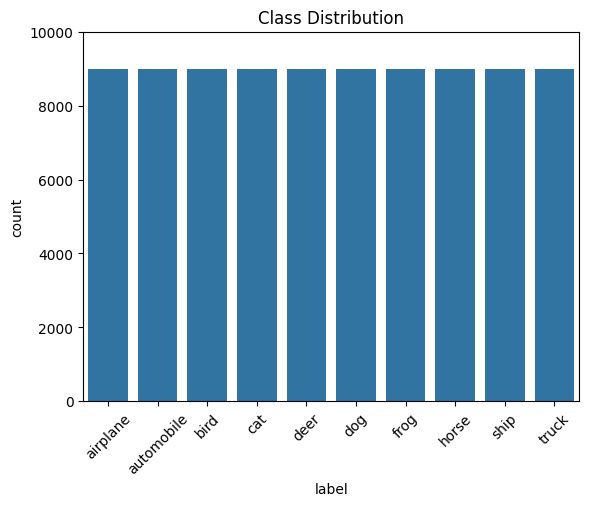

In [6]:
sns.countplot(x="label", data=df, order=df["label"].sort_values().unique())
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.ylim(0, df["label"].value_counts().max() + 1000)
plt.show()

# Sample 4 images

In [7]:
df = df.sample(frac=1).reset_index(drop=True)

sampled_images = df.groupby("label").head(1).head(4)

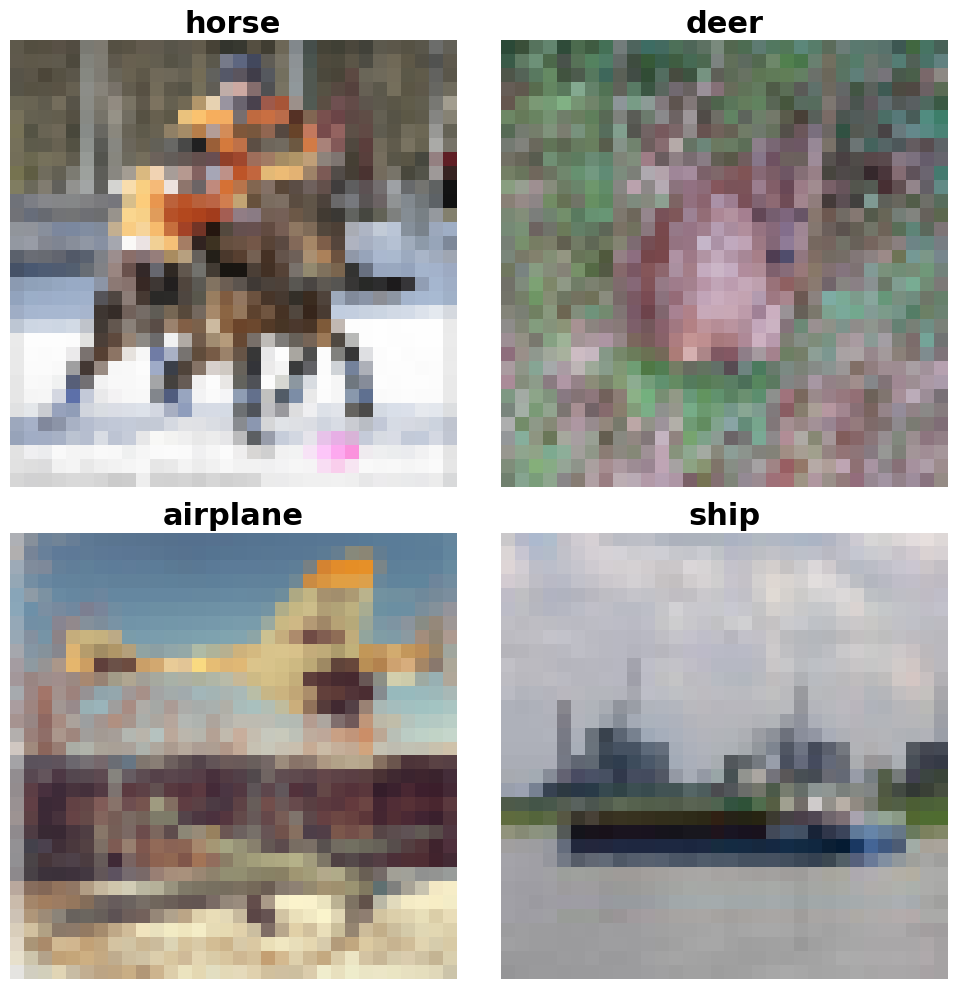

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for image, label, i in zip(
    sampled_images["image"], sampled_images["label"], range(4), strict=False
):
    img = plt.imread(image)
    axes[i].imshow(img)
    axes[i].set_title(label, fontsize=22, fontweight="bold")
    axes[i].axis("off")
plt.tight_layout()
plt.savefig("./plots/sample_images.png", dpi=500)
plt.show()

In [9]:
sampled_images

,image,label
0,../../../data/train/horse/n02380464_22.png,horse
1,../../../data/train/deer/n02434954_4317.png,deer
2,../../../data/train/airplane/n03215191_4721.png,airplane
4,../../../data/train/ship/n02792552_8660.png,ship


# Augmentation Modes (`none`, `standard`, `autoaugment`)

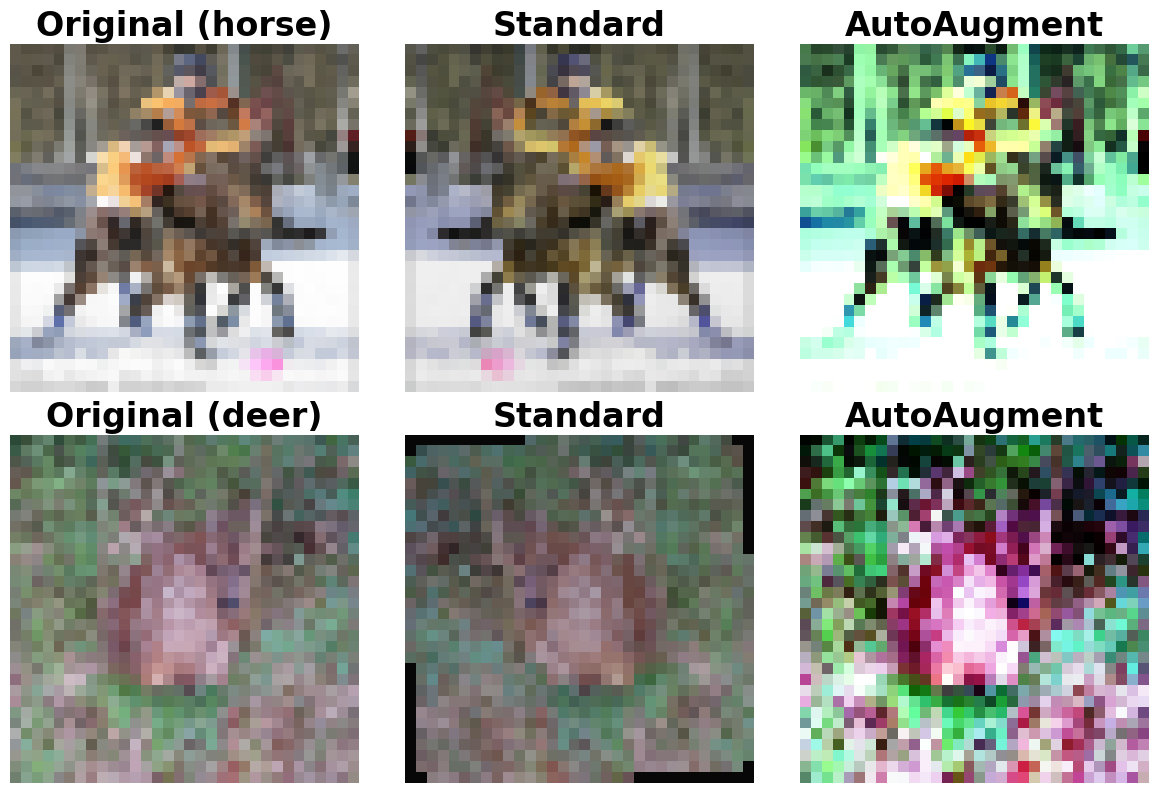

In [10]:
train_transforms_standard = build_transforms(train=True, augmentation="standard")
train_transforms_auto = build_transforms(train=True, augmentation="autoaugment")

selected_samples = sampled_images.iloc[:2].reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for row in range(2):
    sample_path = selected_samples.iloc[row]["image"]
    sample_label = selected_samples.iloc[row]["label"]
    original_img = Image.open(sample_path).convert("RGB")

    axes[row, 0].imshow(original_img)
    axes[row, 0].set_title(f"Original ({sample_label})", fontsize=24, fontweight="bold")
    axes[row, 0].axis("off")

    for col, (mode_name, transform_fn) in enumerate(
        [
            ("Standard", train_transforms_standard),
            ("AutoAugment", train_transforms_auto),
        ],
        start=1,
    ):
        augmented = transform_fn(original_img)
        augmented = augmented * std + mean
        augmented_img = augmented.permute(1, 2, 0).numpy().clip(0, 1)
        axes[row, col].imshow(augmented_img)
        axes[row, col].set_title(mode_name, fontsize=24, fontweight="bold")
        axes[row, col].axis("off")

plt.tight_layout()
plt.savefig("./plots/augmentation_sample.png", dpi=500)
plt.show()

# `standard + MixUp` and `standard + CutMix` (torchvision v2)

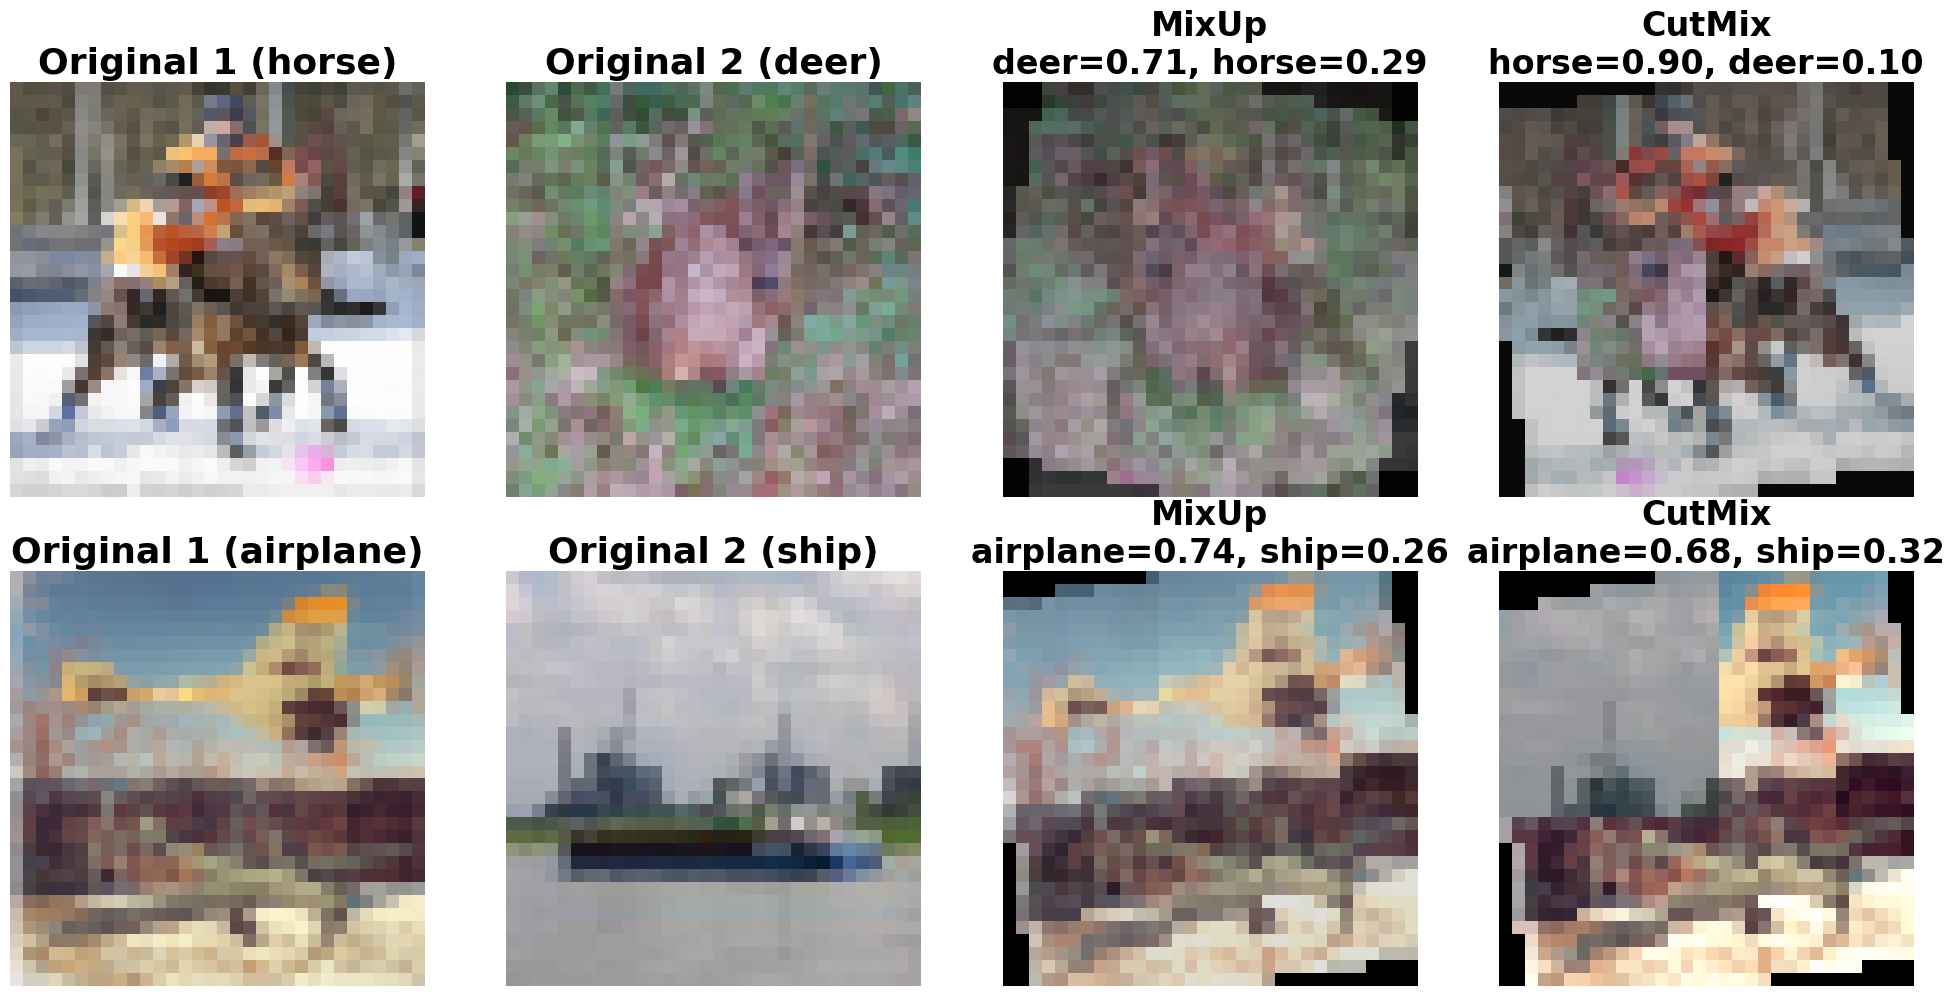

In [11]:
standard_train_transforms = build_transforms(train=True, augmentation="standard")
class_names = sorted(df["label"].unique())
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

mixup = v2.MixUp(alpha=1.0, num_classes=len(class_names))
cutmix = v2.CutMix(alpha=1.0, num_classes=len(class_names))


def denormalize(image_tensor: torch.Tensor) -> np.ndarray:
    image = image_tensor * std + mean
    return image.permute(1, 2, 0).numpy().clip(0, 1)


def mix_pair(row_a: int, row_b: int):
    path_a = sampled_images.iloc[row_a]["image"]
    path_b = sampled_images.iloc[row_b]["image"]
    label_a = sampled_images.iloc[row_a]["label"]
    label_b = sampled_images.iloc[row_b]["label"]

    img_a = Image.open(path_a).convert("RGB")
    img_b = Image.open(path_b).convert("RGB")

    tensor_a = standard_train_transforms(img_a)
    tensor_b = standard_train_transforms(img_b)

    image_batch = torch.stack([tensor_a, tensor_b])
    label_batch = torch.tensor([class_to_idx[label_a], class_to_idx[label_b]], dtype=torch.long)

    mixup_images, mixup_labels = mixup(image_batch, label_batch)
    cutmix_images, cutmix_labels = cutmix(image_batch, label_batch)

    return {
        "img_a": img_a,
        "img_b": img_b,
        "label_a": label_a,
        "label_b": label_b,
        "mixup_image": denormalize(mixup_images[0]),
        "cutmix_image": denormalize(cutmix_images[0]),
        "mixup_label": mixup_labels[0],
        "cutmix_label": cutmix_labels[0],
    }


def format_label_mix(mixed_label: torch.Tensor) -> str:
    values, indices = torch.topk(mixed_label, k=2)
    first = f"{class_names[int(indices[0])]}={float(values[0]):.2f}"
    second = f"{class_names[int(indices[1])]}={float(values[1]):.2f}"
    return f"{first}, {second}"


pair_1 = mix_pair(0, 1)
pair_2 = mix_pair(2, 3)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for row, pair in enumerate([pair_1, pair_2]):
    axes[row, 0].imshow(pair["img_a"])
    axes[row, 0].set_title(f"Original 1 ({pair['label_a']})", fontweight="bold", fontsize=26)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(pair["img_b"])
    axes[row, 1].set_title(f"Original 2 ({pair['label_b']})", fontweight="bold", fontsize=26)
    axes[row, 1].axis("off")

    axes[row, 2].imshow(pair["mixup_image"])
    axes[row, 2].set_title(
        f"MixUp\n{format_label_mix(pair['mixup_label'])}",
        fontweight="bold",
        fontsize=24,
    )
    axes[row, 2].axis("off")

    axes[row, 3].imshow(pair["cutmix_image"])
    axes[row, 3].set_title(
        f"CutMix\n{format_label_mix(pair['cutmix_label'])}",
        fontweight="bold",
        fontsize=24,
    )
    axes[row, 3].axis("off")

plt.tight_layout()
plt.savefig("./plots/mixing_methods.png", dpi=500)
plt.show()